# 03 — Multi-File Binary Classification

Pools all 8 CICIDS2017 files and runs an 80/20 stratified binary classification experiment.

In [8]:
%run 00_data_loader.ipynb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

Config loaded
preprocess_binary() defined
load_all_datasets() defined


## 1. Load All 8 Datasets

In [9]:
datasets = load_all_datasets()
print(f"Loaded: {list(datasets.keys())}")

Loading 8 dataset(s): ['monday', 'bruteforce', 'dos', 'web_attacks', 'infiltration', 'botnet', 'portscan', 'ddos']

  [monday]  Monday-WorkingHours.pcap_ISCX.csv
           raw (529918, 79)  ->  clean (502650, 81)  (attack rate 0.0%)
  [bruteforce]  Tuesday-WorkingHours.pcap_ISCX.csv
           raw (445909, 79)  ->  clean (421626, 81)  (attack rate 2.2%)
  [dos]  Wednesday-workingHours.pcap_ISCX.csv
           raw (692703, 79)  ->  clean (610492, 81)  (attack rate 31.7%)
  [web_attacks]  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
           raw (170366, 79)  ->  clean (164179, 81)  (attack rate 1.3%)
  [infiltration]  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
           raw (288602, 79)  ->  clean (252790, 81)  (attack rate 0.0%)
  [botnet]  Friday-WorkingHours-Morning.pcap_ISCX.csv
           raw (191033, 79)  ->  clean (184044, 81)  (attack rate 1.1%)
  [portscan]  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
           raw (286467, 79)  ->  clea

## 2. Pool and Split

In [10]:
combined = pd.concat(datasets.values(), ignore_index=True)
print("Combined shape:", combined.shape)
print("\nRows per source file:")
print(combined["Source_File"].value_counts())
print("\nBinary label distribution:")
print(combined["Label_Binary"].value_counts())

Combined shape: (2572640, 81)

Rows per source file:
Source_File
DoS             610492
Monday          502650
BruteForce      421626
Infiltration    252790
DDoS            223082
PortScan        213777
Botnet          184044
WebAttacks      164179
Name: count, dtype: int64

Binary label distribution:
Label_Binary
0    2146899
1     425741
Name: count, dtype: int64


In [11]:
X = combined.drop(columns=["Label", "Label_Binary", "Source_File"])
y = combined["Label_Binary"]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "  X_test:", X_test.shape)
print("Train label counts:\n", y_train.value_counts())

X_train: (2058112, 78)   X_test: (514528, 78)
Train label counts:
 Label_Binary
0    1717519
1     340593
Name: count, dtype: int64


## 3. Logistic Regression

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr   = log_reg.predict(X_test_scaled)
y_scores_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print("  Accuracy: ", round(accuracy_score(y_test, y_pred_lr), 4))
print("  Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("  Recall:   ", round(recall_score(y_test, y_pred_lr), 4))
print("  F1:       ", round(f1_score(y_test, y_pred_lr), 4))
print("  ROC-AUC:  ", round(roc_auc_score(y_test, y_scores_lr), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression
  Accuracy:  0.9404
  Precision: 0.744
  Recall:    0.976
  F1:        0.8443
  ROC-AUC:   0.9883

Confusion Matrix:
 [[400781  28599]
 [  2045  83103]]


## 4. Random Forest

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf   = rf_model.predict(X_test)
y_scores_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("  Accuracy: ", round(accuracy_score(y_test, y_pred_rf), 4))
print("  Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("  Recall:   ", round(recall_score(y_test, y_pred_rf), 4))
print("  F1:       ", round(f1_score(y_test, y_pred_rf), 4))
print("  ROC-AUC:  ", round(roc_auc_score(y_test, y_scores_rf), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest
  Accuracy:  0.9986
  Precision: 0.9966
  Recall:    0.995
  F1:        0.9958
  ROC-AUC:   0.9998

Confusion Matrix:
 [[429087    293]
 [   425  84723]]


## 5. Results Summary

In [14]:
pd.DataFrame([
    {"Model": "Logistic Regression",
     "Accuracy": accuracy_score(y_test, y_pred_lr), "Precision": precision_score(y_test, y_pred_lr),
     "Recall": recall_score(y_test, y_pred_lr), "F1": f1_score(y_test, y_pred_lr),
     "ROC_AUC": roc_auc_score(y_test, y_scores_lr)},
    {"Model": "Random Forest",
     "Accuracy": accuracy_score(y_test, y_pred_rf), "Precision": precision_score(y_test, y_pred_rf),
     "Recall": recall_score(y_test, y_pred_rf), "F1": f1_score(y_test, y_pred_rf),
     "ROC_AUC": roc_auc_score(y_test, y_scores_rf)},
]).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.9404,0.7440,0.976,0.8443,0.9883
1,Random Forest,0.9986,0.9966,0.995,0.9958,0.9998


In [ ]:
## CICIDS2017 vs CSE-CIC-IDS2018 Comparison

In [18]:
import pandas as pd
import numpy as np
import sklearn
import nbformat

print("Everything imported correctly")

Everything imported correctly


In [19]:
%run data_loader.ipynb

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

datasets_2017 = load_all_datasets()

sampled_2017 = []
for name, temp_df in datasets_2017.items():
    if len(temp_df) > 5000:
        sampled_2017.append(temp_df.sample(n=5000, random_state=42))
    else:
        sampled_2017.append(temp_df)

df_2017 = pd.concat(sampled_2017, ignore_index=True)

df_2018 = load_cicids2018(max_rows_per_file=2000)

print("2017 shape:", df_2017.shape)
print("2018 shape:", df_2018.shape)

Config loaded
preprocess_binary() defined
load_all_datasets() defined
Project root: /Users/sharadpatel/Desktop/IDS_project_clean
2018 data folder exists: True
Loading 8 dataset(s): ['monday', 'bruteforce', 'dos', 'web_attacks', 'infiltration', 'botnet', 'portscan', 'ddos']

  [monday]  Monday-WorkingHours.pcap_ISCX.csv
           raw (529918, 79)  ->  clean (502650, 81)  (attack rate 0.0%)
  [bruteforce]  Tuesday-WorkingHours.pcap_ISCX.csv
           raw (445909, 79)  ->  clean (421626, 81)  (attack rate 2.2%)
  [dos]  Wednesday-workingHours.pcap_ISCX.csv
           raw (692703, 79)  ->  clean (610492, 81)  (attack rate 31.7%)
  [web_attacks]  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
           raw (170366, 79)  ->  clean (164179, 81)  (attack rate 1.3%)
  [infiltration]  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
           raw (288602, 79)  ->  clean (252790, 81)  (attack rate 0.0%)
  [botnet]  Friday-WorkingHours-Morning.pcap_ISCX.csv
           raw (1

In [20]:
def clean_col_name(col):
    return (
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )


def make_binary_target(series):
    s = series.copy()

    # If already numeric 0/1, keep it
    numeric_s = pd.to_numeric(s, errors="coerce")
    non_null_numeric = numeric_s.dropna()

    if len(non_null_numeric) > 0:
        unique_vals = set(non_null_numeric.unique())
        if unique_vals.issubset({0, 1}):
            return numeric_s.astype(int)

    # Otherwise handle text labels
    return s.apply(
        lambda x: 0 if str(x).strip().lower() in ["benign", "normal", "0"] else 1
    )


def prep_binary_df(df):
    temp = df.copy()
    
    temp.columns = [clean_col_name(c) for c in temp.columns]
    temp = temp.replace([np.inf, -np.inf], np.nan)

    if "label_binary" in temp.columns:
        y = make_binary_target(temp["label_binary"])
    elif "label" in temp.columns:
        y = make_binary_target(temp["label"])
    else:
        raise ValueError("No label column found")

    drop_cols = ["label", "label_binary", "sourcefile", "timestamp"]
    feature_cols = [c for c in temp.columns if c not in drop_cols]

    X = temp[feature_cols].copy()

    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    X = X.dropna(axis=1, how="all")

    # Keep rows where y is valid
    valid_rows = y.notna()
    X = X.loc[valid_rows]
    y = y.loc[valid_rows].astype(int)

    return X, y, X.columns.tolist()


X17, y17, cols17 = prep_binary_df(df_2017)
X18, y18, cols18 = prep_binary_df(df_2018)

common_cols = sorted(list(set(cols17).intersection(set(cols18))))

print("2017 numeric columns:", len(cols17))
print("2018 numeric columns:", len(cols18))
print("Common numeric columns:", len(common_cols))

print("\nFirst 20 common columns:")
print(common_cols[:20])

X17 = X17[common_cols]
X18 = X18[common_cols]

print("\nFinal X17 shape:", X17.shape)
print("Final X18 shape:", X18.shape)

print("\n2017 label counts:")
print(y17.value_counts())

print("\n2018 label counts:")
print(y18.value_counts())

2017 numeric columns: 78
2018 numeric columns: 79
Common numeric columns: 27

First 20 common columns:
['active_max', 'active_mean', 'active_min', 'active_std', 'bwd_iat_max', 'bwd_iat_mean', 'bwd_iat_min', 'bwd_iat_std', 'bwd_psh_flags', 'bwd_urg_flags', 'cwe_flag_count', 'down_up_ratio', 'flow_duration', 'flow_iat_max', 'flow_iat_mean', 'flow_iat_min', 'flow_iat_std', 'fwd_iat_max', 'fwd_iat_mean', 'fwd_iat_min']

Final X17 shape: (40000, 27)
Final X18 shape: (20000, 27)

2017 label counts:
label_binary
0    33168
1     6832
Name: count, dtype: int64

2018 label counts:
label_binary
1    10227
0     9773
Name: count, dtype: int64


In [21]:
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=500))
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(max_depth=8, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=25, max_depth=8, random_state=42))
    ])
}


def get_safe_auc(model, X_test, y_test):
    try:
        if not hasattr(model, "predict_proba"):
            return np.nan

        probs_all = model.predict_proba(X_test)

        # If the model only learned one class, AUC cannot be calculated normally
        if probs_all.shape[1] < 2:
            return np.nan

        # Get probability for class 1 = Attack
        if hasattr(model, "classes_"):
            classes = list(model.classes_)
            if 1 in classes:
                attack_index = classes.index(1)
                probs = probs_all[:, attack_index]
            else:
                return np.nan
        else:
            probs = probs_all[:, 1]

        # AUC needs both classes in y_test
        if len(set(y_test)) < 2:
            return np.nan

        return roc_auc_score(y_test, probs)

    except Exception:
        return np.nan


def run_model_set(X, y, dataset_name):
    results = []

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        auc = get_safe_auc(model, X_test, y_test)

        results.append({
            "Dataset": dataset_name,
            "Model": name,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, zero_division=0),
            "Recall": recall_score(y_test, preds, zero_division=0),
            "F1": f1_score(y_test, preds, zero_division=0),
            "ROC_AUC": auc
        })

    return pd.DataFrame(results)


results_2017 = run_model_set(X17, y17, "CICIDS2017")
results_2018 = run_model_set(X18, y18, "CSE-CIC-IDS2018")

comparison_results = pd.concat([results_2017, results_2018], ignore_index=True)
comparison_results

,Dataset,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,CICIDS2017,Dummy,0.8292,0.000000,0.000000,0.000000,0.500000
1,CICIDS2017,Logistic Regression,0.8728,0.929134,0.276347,0.425993,0.702640
2,CICIDS2017,Decision Tree,0.9300,0.824742,0.749415,0.785276,0.965737
3,CICIDS2017,Random Forest,0.9267,0.971926,0.587822,0.732579,0.978586
4,CSE-CIC-IDS2018,Dummy,0.5114,0.511400,1.000000,0.676724,0.500000
5,CSE-CIC-IDS2018,Logistic Regression,0.9034,0.906348,0.904576,0.905461,0.948032
6,CSE-CIC-IDS2018,Decision Tree,0.9710,0.980861,0.962065,0.971372,0.992761
7,CSE-CIC-IDS2018,Random Forest,0.9732,0.987525,0.959718,0.973423,0.994677


In [22]:
def cross_dataset_test(X_train, y_train, X_test, y_test, train_name, test_name):
    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, probs)
        else:
            auc = np.nan

        results.append({
            "Train On": train_name,
            "Test On": test_name,
            "Model": name,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, zero_division=0),
            "Recall": recall_score(y_test, preds, zero_division=0),
            "F1": f1_score(y_test, preds, zero_division=0),
            "ROC_AUC": auc
        })

    return pd.DataFrame(results)


cross_17_to_18 = cross_dataset_test(
    X17, y17,
    X18, y18,
    "CICIDS2017",
    "CSE-CIC-IDS2018"
)

cross_18_to_17 = cross_dataset_test(
    X18, y18,
    X17, y17,
    "CSE-CIC-IDS2018",
    "CICIDS2017"
)

cross_year_results = pd.concat([cross_17_to_18, cross_18_to_17], ignore_index=True)
cross_year_results

,Train On,Test On,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,CICIDS2017,CSE-CIC-IDS2018,Dummy,0.488650,0.000000,0.000000,0.000000,0.500000
1,CICIDS2017,CSE-CIC-IDS2018,Logistic Regression,0.342350,0.040804,0.012711,0.019384,0.444987
2,CICIDS2017,CSE-CIC-IDS2018,Decision Tree,0.485600,0.494072,0.248558,0.330731,0.553102
3,CICIDS2017,CSE-CIC-IDS2018,Random Forest,0.592150,0.787340,0.277305,0.410153,0.748452
4,CSE-CIC-IDS2018,CICIDS2017,Dummy,0.170800,0.170800,1.000000,0.291766,0.500000
5,CSE-CIC-IDS2018,CICIDS2017,Logistic Regression,0.437225,0.163440,0.557231,0.252747,0.453354
6,CSE-CIC-IDS2018,CICIDS2017,Decision Tree,0.607800,0.181255,0.368560,0.243003,0.474759
7,CSE-CIC-IDS2018,CICIDS2017,Random Forest,0.692625,0.231495,0.344701,0.276977,0.569751


In [23]:
comparison_results.to_csv("../results/year_dataset_model_comparison.csv", index=False)
cross_year_results.to_csv("../results/cross_year_generalization_results.csv", index=False)

print("Saved comparison results.")

Saved comparison results.


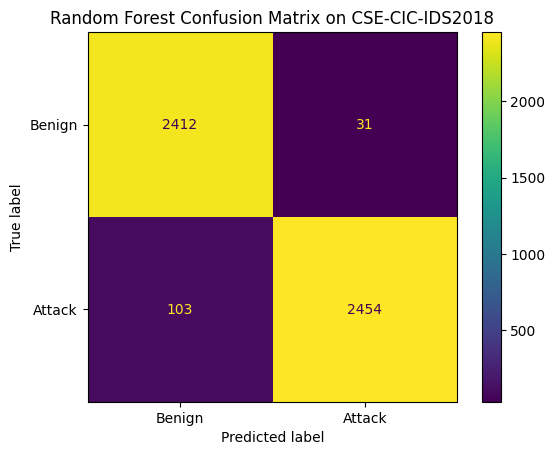

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = models["Random Forest"]

X_train, X_test, y_train, y_test = train_test_split(
    X18,
    y18,
    test_size=0.25,
    random_state=42,
    stratify=y18
)

best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Attack"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix on CSE-CIC-IDS2018")
plt.savefig("../results/random_forest_confusion_matrix_2018.png", bbox_inches="tight")
plt.show()

### Confusion Matrix Takeaway

The confusion matrix gives a more detailed view of the Random Forest model’s performance on the CSE-CIC-IDS2018 data. Instead of only looking at accuracy, this shows how many benign and attack records were classified correctly or incorrectly. This matters for intrusion detection because false positives can create unnecessary alerts, while false negatives can allow attack traffic to go undetected.

Even though the model performs well overall, this comparison is still limited because it uses sampled rows from a public dataset instead of live network traffic.